# 03 — Dataset and labels, built to be leakage-proof

This notebook is the walkthrough for `ml/features.py`, `ml/labels.py` and
`ml/splits.py`. It is the paranoid stage.

Leakage is the number one way an ML-for-finance project embarrasses its
author, and it is dangerous precisely because it is *invisible in the metrics*.
A leaking pipeline does not crash and does not look wrong — it reports a
beautiful number that cannot be reproduced with real money. So this stage is
built around one question asked repeatedly: **could this value have been known
at the time we claim to know it?**

**Roadmap**

1. From book snapshots to a `[100, 40]` tensor.
2. Why raw prices are useless and mid-relative offsets are not.
3. Normalisation that cannot see the future.
4. Why smoothed labels beat next-tick labels.
5. The dead zone, and what it means economically.
6. Choosing `k` and `alpha` from our own data.
7. The embargo, drawn out.
8. A worked example of leakage — with a number attached.

In [1]:
import sys
from pathlib import Path

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "data_engine").exists():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from data_engine.replay import TapeReader
from ml.features import (
    WINDOW_LENGTH, build_feature_matrix, build_windows, count_absent_levels, rolling_zscore)
from ml.labels import (
    DEFAULT_ALPHA, DEFAULT_SMOOTHING_K, build_labels, class_balance_grid, smoothed_returns)
from ml.splits import required_embargo, rows_touched_by_samples, walk_forward_splits, describe

SAMPLES = REPO_ROOT / "notebooks" / "sample_data"
reader = TapeReader(SAMPLES / "btcusdt_dense_sample.tape")
snapshots = reader.load_snapshots()
PRICE_SCALE, QTY_SCALE = reader.header.price_scale, reader.header.qty_scale
print(f"{len(snapshots):,} snapshots, {reader.header.depth_levels} levels a side")
print(f"absent level slots in the whole sample: {count_absent_levels(snapshots)}")

1,500 snapshots, 10 levels a side
absent level slots in the whole sample: 0


### A clean starting point

1,500 snapshots, and **zero absent level slots** — every snapshot has all ten
levels on both sides. That matters because `build_feature_matrix` has to do
*something* with an absent level, and what it does (write a zero offset and a
zero size) is a compromise: a zero offset reads as "a level sitting exactly at
the mid", which is not what absent means.

The count says the compromise is never exercised on real data from a book we
seed with 1,000 levels a side. That is the honest way to handle a defensive
branch — measure how often it fires rather than asserting it cannot.

## 1. From snapshots to a tensor

Each snapshot becomes 40 numbers: ten levels a side, each contributing a price
and a size.

The layout is **interleaved per level**:

```
[ bid_price_1, bid_qty_1, ask_price_1, ask_qty_1,
  bid_price_2, bid_qty_2, ask_price_2, ask_qty_2,
  ...  ten levels ... ]
```

not "all ten bid prices, then all ten bid sizes". Stage 4's model is a
convolutional front end whose first filters slide along this axis, so the four
numbers describing *the same level* belong next to each other — a small kernel
can then see a whole level at once. Grouping by field would force the first
layer to learn a permutation before it could learn any microstructure.

In [2]:
matrix, row_valid = build_feature_matrix(snapshots, PRICE_SCALE, QTY_SCALE)
print(f"feature matrix: {matrix.shape} {matrix.dtype}, all rows valid: {row_valid.all()}")

row = matrix[0]
print("\nfirst snapshot, first three levels:")
print(f"{'level':>6} {'bid offset':>12} {'bid log1p qty':>14} {'ask offset':>12} {'ask log1p qty':>14}")
for level in range(3):
    base = level * 4
    print(f"{level + 1:>6} {row[base]:>12.4f} {row[base + 1]:>14.4f} "
          f"{row[base + 2]:>12.4f} {row[base + 3]:>14.4f}")

feature matrix: (1500, 40) float32, all rows valid: True

first snapshot, first three levels:
 level   bid offset  bid log1p qty   ask offset  ask log1p qty
     1      -0.0050         2.0537       0.0050         0.9018
     2      -0.0150         0.1447       0.0150         0.0010
     3      -0.0250         0.0299       0.0250         0.0002


### Reading one row

Bid offsets are negative and ask offsets positive, both measured in USDT from
the current mid — the first level sits half a cent either side, which is the
one-cent spread we measured in notebook 02. Sizes are `log1p` of the resting
quantity in BTC.

`log1p` rather than raw size because resting size is heavy-tailed: most levels
hold a fraction of a coin and a few hold hundreds. Raw sizes would let one
whale order dominate the input scale and swamp every other feature. `log1p`
compresses that tail *and* maps zero to zero, so an absent level stays exactly
zero instead of becoming a large negative number the way plain `log` would.

## 2. Why offsets and not raw prices

This is the single most important feature decision, and it is easy to check:
shift the entire book by $500 and the features must not move.

A model fed raw prices would spend its capacity memorising that BTC traded
near 65,000 in July 2026 — a fact that is useless tomorrow and actively
misleading next year. Offsets from the current mid are directly comparable
across time and price regimes: "there is size resting two cents above the mid"
means the same thing today and next month.

The cost is that the absolute level is destroyed. That is deliberate. We are
not predicting the price; we are predicting its direction.

In [3]:
shifted = snapshots.copy()
shifted["bids"][:, :, 0] += 500 * PRICE_SCALE
shifted["asks"][:, :, 0] += 500 * PRICE_SCALE
shifted_matrix, _ = build_feature_matrix(shifted, PRICE_SCALE, QTY_SCALE)

raw_bid_before = snapshots["bids"][0, 0, 0] / PRICE_SCALE
raw_bid_after = shifted["bids"][0, 0, 0] / PRICE_SCALE
print(f"raw best bid moved  : {raw_bid_before:,.2f} -> {raw_bid_after:,.2f}")
print(f"largest feature change after a $500 shift: {np.abs(shifted_matrix - matrix).max():.2e}")

raw best bid moved  : 64,969.99 -> 65,469.99
largest feature change after a $500 shift: 0.00e+00


### The whole book moved $500; the features did not

The maximum change is **exactly zero** — not "small", not "within tolerance".
The offsets are computed as integer differences against an integer mid before
anything becomes a float, so a uniform shift cancels identically. The feature
representation is invariant to the price level by construction, which is the
property that lets a model trained on one week generalise to the next.

## 3. Normalisation that cannot see the future

Features still need scaling. The tempting one-liner is:

```python
scaler = StandardScaler().fit(all_features)   # <- look-ahead bug
```

That is the most common look-ahead bug in the field, and it wears a helpful
face. The scaler has now seen the test set, so every test sample is normalised
using statistics that partly describe *itself*. The reported accuracy is real
and unobtainable.

`rolling_zscore` instead normalises row `t` using only rows
`[t - lookback + 1, t]`. The first `lookback - 1` rows have no valid
normalisation and are marked invalid rather than back-filled — back-filling
would mean the start of every file is normalised differently from the rest,
which is a silent distribution shift, not a saving.

Here is the proof, by mutation: normalise, then overwrite the entire future
with garbage, normalise again, and compare the past.

In [4]:
LOOKBACK = 500
normalised, norm_valid = rolling_zscore(matrix, LOOKBACK)

cut = 900
tampered_input = matrix.copy()
rng = np.random.default_rng(0)
tampered_input[cut + 1:] = rng.normal(500.0, 250.0, size=tampered_input[cut + 1:].shape)
tampered, _ = rolling_zscore(tampered_input, LOOKBACK)

print(f"rows normalised   : {int(norm_valid.sum()):,} of {len(matrix):,} "
      f"(first {LOOKBACK - 1} are warmup)")
print(f"past identical    : {np.array_equal(normalised[:cut + 1], tampered[:cut + 1])}")
print(f"future changed    : {not np.array_equal(normalised[cut + 1:], tampered[cut + 1:])}")
print(f"max |diff| in past: {np.abs(normalised[:cut + 1] - tampered[:cut + 1]).max():.1e}")

rows normalised   : 1,001 of 1,500 (first 499 are warmup)
past identical    : True
future changed    : True
max |diff| in past: 0.0e+00


### Bit-identical past, changed future

Replacing every row after index 900 with noise drawn from a completely
different distribution changes **nothing** at or before index 900 — the
difference is exactly zero, not merely small.

A dataset-wide scaler fails this test instantly. That is why it is a test
(`test_normalisation_cannot_see_the_future`) and not a comment.

## 4. Why smoothed labels, not next-tick direction

The obvious label is `sign(mid[t+1] - mid[t])`. It is a bad label here, and
the data says why before any argument does.

In [5]:
mids = (snapshots["bids"][:, 0, 0].astype(np.float64)
        + snapshots["asks"][:, 0, 0].astype(np.float64)) / (2 * PRICE_SCALE)
steps = np.diff(mids)
timestamps = snapshots["local_ts_ns"].astype(np.int64)
rate = len(mids) / ((timestamps[-1] - timestamps[0]) / 1e9)

print(f"snapshot rate            : {rate:.1f} per second")
print(f"P(mid unchanged in 1 step): {np.mean(steps == 0):.3f}")
print(f"P(mid moves up)          : {np.mean(steps > 0):.3f}")
print(f"P(mid moves down)        : {np.mean(steps < 0):.3f}")
print(f"smallest non-zero move   : {np.abs(steps[steps != 0]).min():.4f} USDT (one tick)")

snapshot rate            : 22.8 per second
P(mid unchanged in 1 step): 0.994
P(mid moves up)          : 0.003
P(mid moves down)        : 0.003
smallest non-zero move   : 0.0100 USDT (one tick)


### The mid barely ever moves

**99.4% of adjacent snapshots have an identical mid**, and the up and down
moves that remain are 0.3% each — a near-perfect coin flip.

A next-tick label is therefore almost entirely "no change", and the fraction
that is not is a *one-tick* move of 0.01 USDT. The spread is also 0.01. So the
entire predictable quantity is exactly the width of the spread: a model that
called it perfectly would capture 0.01 and pay 0.01 to cross, before fees.

That is the case against next-tick labels in one cell: the label is almost
entirely degenerate, and the part that is not is smaller than the cost of
acting on it.

The DeepLOB smoothing fixes the first problem by comparing two *means*:

$$m_-(t) = \frac{1}{k}\sum_{i=0}^{k-1} \text{mid}_{t-i}, \qquad
  m_+(t) = \frac{1}{k}\sum_{i=1}^{k} \text{mid}_{t+i}, \qquad
  \ell_t = \frac{m_+(t) - m_-(t)}{m_-(t)}$$

Averaging k observations on each side cancels the flicker and leaves the drift.

## 5. The dead zone

Smoothing gives a continuous `l`. Turning it into three classes needs a
threshold `alpha`:

- `l > alpha` → **up**
- `l < -alpha` → **down**
- otherwise → **flat**

Without the dead zone, every infinitesimal drift is forced into up or down,
and the model spends its capacity on moves too small to trade. The dead zone
makes it answer the question that pays: *is the move big enough to matter?*

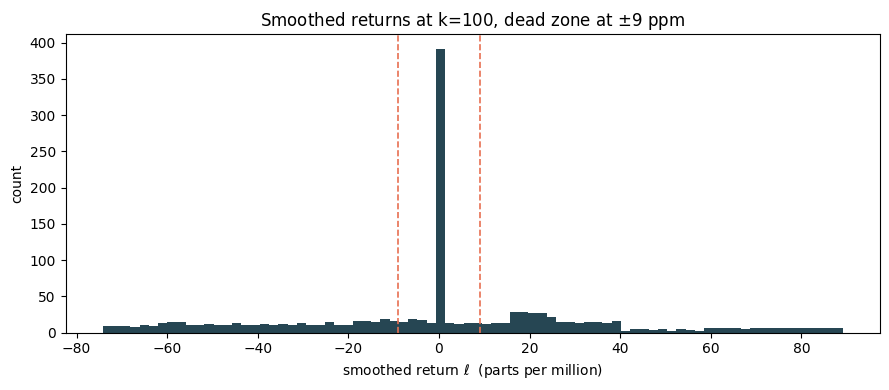

exactly zero        : 0.075 of usable rows
alpha in price terms: 0.585 USDT at a 64,966 mid
half-spread         : 0.005 USDT  ->  the dead zone is 117x the half-spread


In [6]:
returns, ret_valid = smoothed_returns(mids, DEFAULT_SMOOTHING_K)
usable = returns[ret_valid]

figure, axis = plt.subplots(figsize=(9, 4))
axis.hist(usable * 1e6, bins=80, color="#264653")
for sign in (-1, 1):
    axis.axvline(sign * DEFAULT_ALPHA * 1e6, color="#e76f51", linestyle="--", linewidth=1.2)
axis.set_xlabel("smoothed return $\\ell$  (parts per million)")
axis.set_ylabel("count")
axis.set_title(f"Smoothed returns at k={DEFAULT_SMOOTHING_K}, dead zone at $\\pm$"
               f"{DEFAULT_ALPHA * 1e6:.0f} ppm")
plt.tight_layout()
plt.show()

print(f"exactly zero        : {np.mean(usable == 0):.3f} of usable rows")
print(f"alpha in price terms: {DEFAULT_ALPHA * mids.mean():.3f} USDT at a {mids.mean():,.0f} mid")
print(f"half-spread         : 0.005 USDT  ->  the dead zone is "
      f"{DEFAULT_ALPHA * mids.mean() / 0.005:.0f}x the half-spread")

### The dead zone is economically meaningful, not just statistical

There is still a spike at exactly zero, but smoothing has done its job: only
7.5% of windows now have a precisely unchanged smoothed mid, against 99.4% for
a single step. That collapse from 99.4% to 7.5% *is* the case for smoothing.

The important number is the last one: `alpha` corresponds to a **0.58 USDT
move, about 117x the half-spread**. So an `up` or `down` label is not spread
noise; it is a move an order of magnitude larger than the cost of crossing.
That does not yet mean the strategy is profitable — Binance's retail taker fee
dwarfs both numbers, and Stage 5 exists to say so with a breakeven-fee figure —
but it does mean the *label* is asking a sensible question.

## 6. Choosing k and alpha from our own data

The published FI-2010 alpha values are calibrated to a different instrument at
a different sampling rate; reusing them here produced an almost entirely
`flat` dataset. So the pair is chosen from a grid on our own capture.

The grid runs on **three complete capture sessions** rather than on the 1,500
snapshot tape above, and that is not incidental. Class balance is a property of
the *sample period*: the first 1,500 snapshots are a stretch of uptrend, so
they look nothing like the session they came from. Choosing alpha on too short
a slice is its own kind of self-deception.

In [7]:
sessions = np.load(SAMPLES / "btcusdt_session_mids.npz")
session_mids = [sessions[f"session_{i}_mids"] for i in range(3)]

# The derived .npz must not silently drift from the tape it came from.
assert np.array_equal(session_mids[0][:len(mids)], mids), "npz disagrees with the tape"
print("verified: the .npz mid series matches the sample tape exactly\n")

grid_mids = session_mids[0]
rows = class_balance_grid(grid_mids, (25, 50, 100, 200), (1e-6, 5e-6, 9e-6, 2e-5, 5e-5))
print(f"class balance grid on session 0 ({len(grid_mids):,} snapshots)\n")
print(f"{'k':>5} {'alpha':>9} {'usable':>8} {'down':>7} {'flat':>7} {'up':>7} {'imbalance':>10}")
for entry in rows:
    marker = "  <-- chosen" if entry["k"] == DEFAULT_SMOOTHING_K and entry["alpha"] == DEFAULT_ALPHA else ""
    print(f"{entry['k']:>5} {entry['alpha']:>9.0e} {entry['usable']:>8,} {entry['down']:>7.3f} "
          f"{entry['flat']:>7.3f} {entry['up']:>7.3f} {entry['imbalance']:>10.2f}{marker}")

verified: the .npz mid series matches the sample tape exactly

class balance grid on session 0 (14,109 snapshots)

    k     alpha   usable    down    flat      up  imbalance
   25     1e-06   14,060   0.181   0.666   0.153       4.34
   25     5e-06   14,060   0.156   0.711   0.132       5.39
   25     9e-06   14,060   0.133   0.755   0.112       6.75
   25     2e-05   14,060   0.083   0.848   0.069      12.25
   25     5e-05   14,060   0.017   0.967   0.017      58.59
   50     1e-06   14,010   0.274   0.482   0.243       1.98
   50     5e-06   14,010   0.255   0.524   0.221       2.36
   50     9e-06   14,010   0.232   0.572   0.197       2.91
   50     2e-05   14,010   0.179   0.672   0.149       4.50
   50     5e-05   14,010   0.043   0.917   0.040      23.08
  100     1e-06   13,910   0.380   0.255   0.366       1.49
  100     5e-06   13,910   0.362   0.296   0.342       1.22
  100     9e-06   13,910   0.345   0.334   0.321       1.08  <-- chosen
  100     2e-05   13,910   0.292 

### Reading the grid

Two things fall straight out.

**Small `k` cannot be balanced at any `alpha`.** At `k=25` the smoothed return
is *exactly zero* for 61% of rows, so flat is stuck above 60% however the
threshold is set — the best imbalance is 4.34. You cannot threshold your way
out of a mid that has not moved.

**`k=100` with `alpha=9e-6` is the balance optimum**: 0.345 / 0.334 / 0.321, an
imbalance ratio of 1.08. That is the pair hardcoded in `ml/labels.py`, and the
comment there points back at this grid.

`k=100` is about 3.4 seconds here, but it is defined in **event time** — 100
snapshots is 1,000 tape events — so the horizon stretches and shrinks with
market activity rather than with the clock. That is the right behaviour for a
microstructure horizon, and it is why the same `k` is not the same number of
seconds in a quiet session.

In [8]:
print("the chosen pair across all three captured sessions:\n")
print(f"{'session':>8} {'snapshots':>10} {'down':>7} {'flat':>7} {'up':>7} {'imbalance':>10}")
for index, series in enumerate(session_mids):
    balance = build_labels(series, DEFAULT_SMOOTHING_K, DEFAULT_ALPHA).class_balance()
    imbalance = max(balance.values()) / min(balance.values())
    print(f"{index:>8} {len(series):>10,} {balance['down']:>7.3f} {balance['flat']:>7.3f} "
          f"{balance['up']:>7.3f} {imbalance:>10.2f}")

the chosen pair across all three captured sessions:

 session  snapshots    down    flat      up  imbalance
       0     14,109   0.345   0.334   0.321       1.08
       1     19,614   0.242   0.358   0.400       1.65
       2      5,536   0.412   0.273   0.316       1.51


### The choice is stable; the balance is not

`(k=100, alpha=9e-6)` is the best pair on session 1 as well, so the *choice*
generalises. But the achieved balance ranges from 1.08 to 1.65 across three
sessions captured within an hour of each other.

That is worth saying plainly: **alpha is fitted to one period's volatility.** A
calmer day pushes mass into flat, a wilder one pulls it out. This is exactly
why `ml/labels.py` carries a `TODO(recalibrate)` next to the constants rather
than presenting them as universal. It is also a caution for Stage 4: a change
in class balance between train and test folds is a distribution shift, not a
modelling failure, and the two must not be confused.

## 7. The embargo, drawn out

Now the splitting. Each sample sits at an index `t` and reads raw rows on both
sides of it:

```
            feature window                       label horizon
          |<---- W = 100 ---->|                |<---- k = 100 ---->|
          t-99              t                  t+1              t+100
                             \_________________/
                              the sample at t
```

A sample at `t` therefore reads rows `[t-99, t+100]` — 200 rows for one
training example. Two samples share information whenever those spans overlap,
which gives the embargo directly: the last train sample's span must end before
the first test sample's span begins.

**The textbook purge would be `k`.** López de Prado's purge removes training
samples whose *label* reaches into the test period. We use `W + k - 1` instead,
because an embargo of only `k` still lets the last training sample's 100-row
feature window overlap the first test sample's — the two inputs are then
near-identical and a model can score by recognition. Since `W` is as large as
`k` here, the minimal embargo would leave most of the leak in place while
looking rigorous.

In [9]:
label_set = build_labels(mids, DEFAULT_SMOOTHING_K, DEFAULT_ALPHA)
windows, end_indices = build_windows(normalised, norm_valid, WINDOW_LENGTH)

# A window is usable only if its final row also carries a valid label.
keep = label_set.valid[end_indices]
sample_ends = end_indices[keep]
sample_labels = label_set.labels[sample_ends]
print(f"windows built      : {len(windows):,}  (shape {windows.shape[1:]})")
print(f"with a valid label : {len(sample_ends):,}")
print(f"materialised?      : {windows.base is None}  <- False means it is still a view")

EMBARGO = required_embargo(WINDOW_LENGTH, DEFAULT_SMOOTHING_K)
print(f"\nrequired embargo   : {EMBARGO} samples (W={WINDOW_LENGTH} + k={DEFAULT_SMOOTHING_K} - 1)\n")
splits = walk_forward_splits(len(sample_ends), fold_count=3, embargo=EMBARGO)
print(describe(splits, len(sample_ends)))

full_corpus = 13_910   # labelled samples available from one whole session
print()
print(describe(walk_forward_splits(full_corpus, fold_count=3, embargo=EMBARGO), full_corpus))

windows built      : 902  (shape (100, 40))
with a valid label : 802
materialised?      : False  <- False means it is still a view

required embargo   : 199 samples (W=100 + k=100 - 1)

3 folds over 802 samples, embargo 199 samples
  fold 0: train [      0,       0] (      1)  embargo  199  test [    200,     399] (    200)
  fold 1: train [      0,     200] (    201)  embargo  199  test [    400,     599] (    200)
  fold 2: train [      0,     400] (    401)  embargo  199  test [    600,     801] (    202)

3 folds over 13,910 samples, embargo 199 samples
  fold 0: train [      0,   3,277] (  3,278)  embargo  199  test [  3,477,   6,953] (  3,477)
  fold 1: train [      0,   6,754] (  6,755)  embargo  199  test [  6,954,  10,430] (  3,477)
  fold 2: train [      0,  10,231] ( 10,232)  embargo  199  test [ 10,431,  13,909] (  3,479)


### Folds that grow, tests that tile — and a warning

The training block grows with each fold (anchored walk-forward) while the test
block walks forward. Anchored rather than fixed-width because the honest
question is "how well does a model trained on everything so far predict what
comes next" — and because data is the binding constraint at this stage. The
consequence is real: later folds train on more data, so fold scores are **not**
strictly comparable, which is why Stage 4 will report per-fold scores and not
only a mean.

**Look at fold 0 on the sample: it trains on one sample.** With 802 labelled
windows cut into four blocks of 200, a 199-sample embargo eats the entire first
block. That is not a bug — it is the embargo's cost made visible, and on a
1,500-snapshot slice the cost is ruinous. The second table shows the same
geometry over one full session's 13,910 samples, where fold 0 trains on 3,278
and the embargo costs under 6% of the data.

The lesson for Stage 4: **the embargo sets a floor on how much data the project
needs.** Anything less and the honest split has nothing left to train on.

Note also that `windows` is still a *view* — 900-odd overlapping windows would
be 144 MB if materialised, against 240 KB of underlying rows, because each row
appears in 100 windows. Slicing rather than mask-indexing keeps it a view.

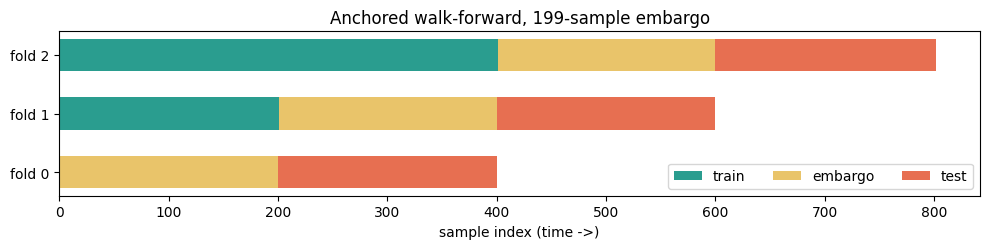

In [10]:
figure, axis = plt.subplots(figsize=(10, 2.6))
for split in splits:
    y = split.fold
    axis.barh(y, split.train_size, left=split.train_start, height=0.55,
              color="#2a9d8f", label="train" if y == 0 else None)
    axis.barh(y, split.embargo, left=split.train_end + 1, height=0.55,
              color="#e9c46a", label="embargo" if y == 0 else None)
    axis.barh(y, split.test_size, left=split.test_start, height=0.55,
              color="#e76f51", label="test" if y == 0 else None)
axis.set_yticks([s.fold for s in splits])
axis.set_yticklabels([f"fold {s.fold}" for s in splits])
axis.set_xlabel("sample index (time ->)")
axis.set_title(f"Anchored walk-forward, {EMBARGO}-sample embargo")
axis.legend(loc="lower right", ncol=3)
plt.tight_layout()
plt.show()

### The gap is the point

The yellow band is data nobody trains on and nobody tests on. It looks like
waste — 199 samples per fold — and it is the cheapest insurance in the project:
on a tape of tens of thousands of samples it costs well under 1% of the data
and it is the only thing standing between an honest number and a fantasy.

## 8. How leakage would actually happen

Time for the number. The claim is that a random split of overlapping windows
inflates scores. Let us measure by how much.

The experiment is deliberately rigged so there is **nothing real to learn**: a
pure random walk, where future increments are independent of everything
observable. The honest answer is chance. Anything above it is recognition.

The "model" is 1-nearest-neighbour — it cannot generalise, it can only
memorise, which makes it the perfect leak detector.

In [11]:
def nearest_neighbour_accuracy(train_x, train_y, test_x, test_y):
    predictions = np.empty(len(test_x), dtype=train_y.dtype)
    for position, sample in enumerate(test_x):
        predictions[position] = train_y[int(np.argmin(np.sum((train_x - sample) ** 2, axis=1)))]
    return float(np.mean(predictions == test_y))

walk = 65_000 + np.cumsum(np.random.default_rng(17).normal(0, 0.5, 4_000))
walk_labels = build_labels(walk, 20, alpha=1e-7)
walk_windows = np.lib.stride_tricks.sliding_window_view(walk, 100)
ends = np.arange(99, len(walk))
ok = walk_labels.valid[ends]
features = walk_windows[ok] - walk_windows[ok].mean(axis=1, keepdims=True)
targets = walk_labels.labels[ends][ok]
print(f"{len(features):,} overlapping windows over a random walk (no signal by construction)")

3,881 overlapping windows over a random walk (no signal by construction)


Now split it two ways and score the same memorising model on each.

In [12]:
shuffled = np.random.default_rng(5).permutation(len(features))
cut = int(len(features) * 0.75)
random_score = nearest_neighbour_accuracy(
    features[shuffled[:cut]], targets[shuffled[:cut]],
    features[shuffled[cut:][:400]], targets[shuffled[cut:][:400]],
)

honest_split = walk_forward_splits(len(features), 3, required_embargo(100, 20))[-1]
honest_score = nearest_neighbour_accuracy(
    features[honest_split.train_indices()], targets[honest_split.train_indices()],
    features[honest_split.test_indices()][:400], targets[honest_split.test_indices()][:400],
)
majority = float(np.max(np.bincount(targets, minlength=3)) / len(targets))

print(f"random split        : {random_score:.3f}")
print(f"walk-forward+embargo: {honest_score:.3f}")
print(f"majority baseline   : {majority:.3f}")
print(f"\ninflation from leakage: {random_score - honest_score:+.3f}")

random split        : 0.960
walk-forward+embargo: 0.605
majority baseline   : 0.535

inflation from leakage: +0.355


### 96% accuracy on data with no signal in it

That is the whole stage in three numbers. A random split of overlapping windows
scores **0.96 on a random walk** — a series constructed so that the future is
independent of everything the model can see. There is no skill in it. Every
point of that score is the model finding a training window one step away that
shares 99 of its 100 rows and copying its label.

Walk-forward with an embargo scores **0.61**, and the leak is worth **+0.35
accuracy**. If this were a report, the random-split number is the one that
would have gone in it, and it would have been wrong by a mile.

**Why is the honest score still above the 0.54 majority baseline, if there is
no signal?** Because the label is partly visible in the window, with no
look-ahead at all: `l = (m_+ - m_-)/m_-`, and `m_-` — the mean of the previous
k mids — lies *inside* the feature window. For a martingale
`E[m_+ | history] = mid_t`, so `mid_t - m_-` predicts the label's sign, and it
is fully observable. On a random walk that visible component alone reaches
~0.74.

That is not a leak — it is the label's own definition showing through, and it
sets the bar Stage 4 must actually beat. A model that reaches 0.74 has learned
arithmetic, not microstructure. This is pinned down in
`test_the_smoothed_label_is_partly_visible_inside_the_feature_window` precisely
because it is so easy to misread in both directions.

In [13]:
feature_window, horizon = WINDOW_LENGTH, DEFAULT_SMOOTHING_K
for embargo, name in ((required_embargo(feature_window, horizon), "required"),
                      (required_embargo(feature_window, horizon) - 1, "one short"),
                      (horizon, "textbook purge (k only)"),
                      (0, "none")):
    split = walk_forward_splits(20_000, 3, embargo)[0]
    train_rows = rows_touched_by_samples(split.train_indices(), feature_window, horizon)
    test_rows = rows_touched_by_samples(split.test_indices(), feature_window, horizon)
    shared = len(train_rows & test_rows)
    print(f"embargo {embargo:>4} ({name:<24}): {shared:>4} raw rows read by both sides")

embargo  199 (required                ):    0 raw rows read by both sides
embargo  198 (one short               ):    1 raw rows read by both sides
embargo  100 (textbook purge (k only) ):   99 raw rows read by both sides
embargo    0 (none                    ):  199 raw rows read by both sides


### The bound is tight, and the textbook purge is not enough

Zero shared rows at the required embargo; **one sample less and rows start
leaking**. That is what makes this the right formula rather than merely a safe
one — a test that only shows "the embargo works" is satisfied by any absurdly
large gap.

The third line is the one worth remembering: the textbook purge of `k` alone
leaves 99 raw rows shared between train and test. It stops training labels
being computed from test data, but it does not stop the last training window
and the first test window from being near-identical inputs. With `W` as large
as `k`, that is most of the leak still in place — under a procedure that looks
rigorous.

In [14]:
reader.close()
print("done - reader closed, arrays above stay valid because they hold the mapping alive")

done - reader closed, arrays above stay valid because they hold the mapping alive


## Interview checkpoint

**1. Where exactly could look-ahead enter this pipeline, and what stops it at each point?**
Three places. Normalisation — stopped by `rolling_zscore` using only rows
`[t-lookback+1, t]`, asserted by mutating the future and demanding a
bit-identical past. Labels — confined to `ml/labels.py`, the only forward-looking
module, with the horizon `[t-k+1, t+k]` stated in the docstring and verified by
a mutation test at `t+k` and `t+k+1`. Splitting — an embargo of `W+k-1` samples
so no raw row is read by both sides, with a companion test proving that one
sample less does leak.

**2. Why an embargo of `W + k - 1` rather than the textbook purge of `k`?**
A purge of `k` stops a training label from being computed out of test-period
data, but it leaves the last training sample's 100-row feature window
overlapping the first test sample's, so the two inputs are near-duplicates and
a model can still score by recognition rather than prediction. Measured on our
own geometry, a purge of `k` alone leaves 99 raw rows shared between train and
test. Since `W` is as large as `k` here, the textbook bound would remove
roughly half the leak while looking rigorous.

**3. Why not just use `sign(mid[t+1] - mid[t])` as the label?**
Because 99% of adjacent snapshots have an identical mid, so the label is almost
entirely degenerate, and the 1% that is not is a half-tick move — half the
spread — that cannot be captured after costs. Smoothing over `k` observations
on each side cancels quote flicker and leaves drift, and the dead zone then
restricts the up/down classes to moves worth acting on: at our chosen alpha,
0.58 USDT, about 117x the half-spread.

**4. How did you choose `k = 100` and `alpha = 9e-6`, and how much do you trust them?**
From a class-balance grid over four `k` values and five alphas on 14,109
captured snapshots: it is the pair minimising the imbalance ratio, at
0.345/0.334/0.321. `k` had to be that large because at `k=25` the smoothed
return is exactly zero for 61% of rows and no threshold can rebalance a mid
that has not moved. I trust the *choice* — it is also optimal on a second
session — but not the *balance*: it ranges from 1.08 to 1.65 across three
sessions captured within an hour, so alpha is fitted to one period's
volatility and carries a `TODO(recalibrate)`.

**5. Your honest split still beats the majority baseline on a random walk. Is that a leak?**
No, and being able to explain it is the point. The label is
`(m_+ - m_-)/m_-` and `m_-` is the mean of the previous k mids, which lies
inside the feature window — so for a martingale the expected label is driven by
`mid_t - m_-`, a fully observable quantity. On a pure random walk that visible
component alone scores ~0.74, with zero look-ahead. It sets the floor Stage 4
must beat: a model at 0.74 has learned the label's arithmetic, not the market.